In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir(r"C:\Users\cesai\Projects\var_backtest")

In [4]:
from src.db import get_connection
from src.ingest import download_prices
from src.ingest import load_raw_to_db

In [5]:
df = download_prices(tickers=['^GSPC'], start='2026-01-01', end='2026-04-15')

[*********************100%***********************]  1 of 1 completed


In [6]:
import numpy as np

df['log_return'] = np.log(df['adj_close'] / df['adj_close'].shift(-1))

In [7]:
from src.models.hs import hs_var 
hs_result = hs_var(df['log_return'], window=20, confidence=0.9)


In [9]:
print(len(hs_result.dropna()))

50


In [ ]:
from src.models.ewma import ewma_var


ewma_result = ewma_var(df['log_return'], confidence=0.99)

print(ewma_result.shape, df['log_return'].shape)   
print(ewma_result.isna().sum())         
ewma_result.dropna().head()

(70,) (70,)
1


1   -0.002619
2   -0.016507
3   -0.013279
4   -0.022875
5   -0.022451
Name: log_return, dtype: float64

In [26]:
from src.models.garch import garch_var

garch_result = garch_var(df['log_return'], window=20, confidence=0.99)

print(garch_result.shape, df['log_return'].shape)   
print(garch_result.isna().sum())         
garch_result.dropna().head()

(70,) (70,)
20


20   -0.029531
21   -0.028947
22   -0.030061
23   -0.025923
24   -0.022726
Name: log_return, dtype: float64

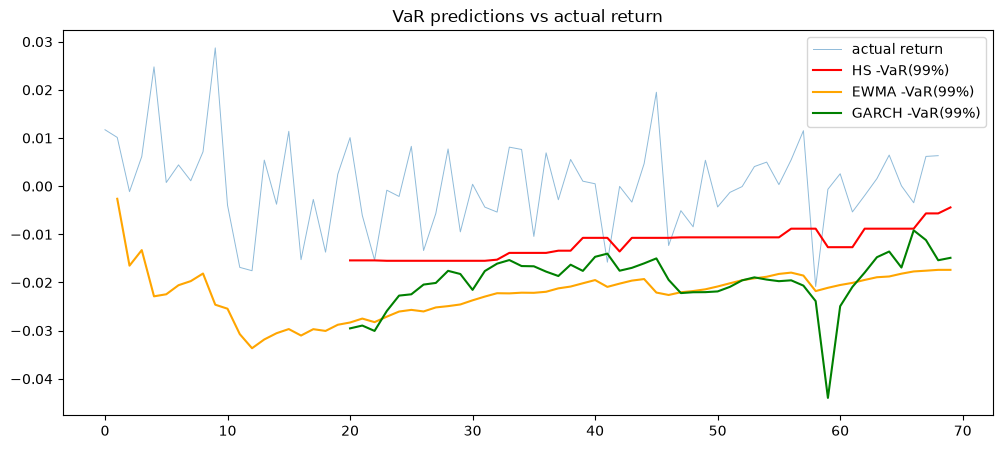

In [31]:
import matplotlib.pyplot as plt

returns = df['log_return']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(returns.index, returns, label='actual return', alpha=0.5, lw=0.7)
ax.plot(hs_result.index, hs_result, label='HS -VaR(99%)', color='red')
ax.plot(ewma_result.index, ewma_result, label='EWMA -VaR(99%)', color='orange')
ax.plot(garch_result.index, garch_result, label='GARCH -VaR(99%)', color='green')
ax.legend()
ax.set_title('VaR predictions vs actual return')
plt.show()

In [32]:
for name, var_series in [('HS', hs_result), ('EWMA', ewma_result), ('GARCH', garch_result)]:
    breach = (returns < var_series).sum()
    total = var_series.notna().sum()
    print(f"{name}: {breach}/{total} 次穿透 ({breach/total:.1%})")

HS: 3/50 次穿透 (6.0%)
EWMA: 0/69 次穿透 (0.0%)
GARCH: 1/50 次穿透 (2.0%)


In [ ]:
from src.db import get_connection
from src.forecast import build

with get_connection(read_only=True) as con:
    df = build(con)

print(df.shape)
print(df.groupby("model").size())        # 每个模型行数
print(df.groupby("model")["var"].agg(["min","max","mean"]))
df[df["var"].notna()].groupby("model").head(2)

[DEBUG] Connect to: C:\Users\cesai\Projects\var_backtest\data\var_backtest.duckdb


c:\Users\cesai\Projects\var_backtest\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.08538. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
c:\Users\cesai\Projects\var_backtest\venv\Lib\site-packages\arch\univariate\base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.08928. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
c:\Users\cesai\Projects\va

(8322, 6)
model
ewma     2774
garch    2774
hs       2774
dtype: int64
            min       max      mean
model                              
ewma  -0.124664 -0.006682 -0.022632
garch -0.234982 -0.001989 -0.023249
hs    -0.122388 -0.002026 -0.017909


,date,model,var,window_size,confidence_level,created_at
0,2015-01-05,hs,NaN,20,0.99,2026-08-21 01:11:03.590442
1,2015-01-06,hs,NaN,20,0.99,2026-08-21 01:11:03.590442
2774,2015-01-05,ewma,NaN,0,0.99,2026-08-21 01:11:03.590442
2775,2015-01-06,ewma,-0.01565,0,0.99,2026-08-21 01:11:03.590442
5548,2015-01-05,garch,NaN,20,0.99,2026-08-21 01:11:03.590442
5549,2015-01-06,garch,NaN,20,0.99,2026-08-21 01:11:03.590442
